
Till now we know:

* convolution → finds patterns
* filters → detect features
* stride & padding → control movement & size

Now the next question:

> **Why are we still keeping so much data?**
> **Can we reduce it without losing important information?**

That’s where pooling comes in.

---

# 🎬 Chapter 5 — Pooling Layer in CNN

## 🎭 Characters

👩 **Riya**
👨‍🏫 **Professor Arjun**
🤖 **Milo**

---

# 🌅 Scene: Too Much Information!

Riya looks at the feature maps and says:

> **Sir… after convolution we still have a lot of data. Isn’t this too heavy?**

Professor Arjun smiles.

> **Exactly. That’s why we use pooling — to reduce size but keep important information.**

Milo writes:

```text id="tav8pd"
Pooling = Reduce size while keeping important features
```

---

# 🧠 Step 1 — What is Pooling?

Pooling is a layer that:

```text id="u66l9z"
Reduces the size of the feature map
```

But it tries to keep:

```text id="b9q8i7"
Important patterns
```

---

# 😄 Funny intuition

Professor Arjun says:

> **Pooling is like summarizing a long story.**
>
> You remove extra details but keep the main idea.

---

# 🧠 Step 2 — Why do we need pooling?

Pooling helps in:

### 1️⃣ Reduce computation

Smaller image → faster training

---

### 2️⃣ Reduce overfitting

Less data → less chance of memorizing noise

---

### 3️⃣ Keep important features

We don’t need every pixel — just important signals

---

# 🧠 Step 3 — Types of Pooling

There are two main types:

| Type            | Idea               |
| --------------- | ------------------ |
| Max Pooling     | take maximum value |
| Average Pooling | take average value |

---

# ⭐ Most important one:

```text id="ol4qst"
Max Pooling
```

Used in most CNNs.

---

# 🧠 Step 4 — How Max Pooling Works

Suppose we have a small feature map:

```text id="fsaf0b"
[ 1  3  2  1 ]
[ 4  6  5  2 ]
[ 7  8  3  1 ]
[ 2  4  6  0 ]
```

Now apply **2×2 pooling**.

---

### Step 1 — Divide into blocks

```text id="i5y6ks"
[ 1  3 | 2  1 ]
[ 4  6 | 5  2 ]
----------------
[ 7  8 | 3  1 ]
[ 2  4 | 6  0 ]
```

---

### Step 2 — Take max from each block

```text id="4p2u9n"
Block 1 → max(1,3,4,6) = 6
Block 2 → max(2,1,5,2) = 5
Block 3 → max(7,8,2,4) = 8
Block 4 → max(3,1,6,0) = 6
```

---

### Final output

```text id="11crqb"
[ 6  5 ]
[ 8  6 ]
```

---

# 🧠 Very simple meaning

Pooling says:

```text id="x0r1a6"
From each small area, keep the most important value
```

---

# 😄 Intuition

Professor Arjun says:

> **If any strong signal exists in a region, max pooling keeps it.**

That’s why it is so powerful.

---

# 🧠 Step 5 — What happens to size?

If we use:

```text id="cynr7o"
2 × 2 pooling
stride = 2
```

Then:

```text id="8k4l9k"
Size becomes half
```

Example:

```text id="zzh5fr"
28×28 → 14×14
```

---

# 🧠 Step 6 — Pooling vs Convolution

| Layer       | Purpose       |
| ----------- | ------------- |
| Convolution | find patterns |
| Pooling     | reduce size   |

---

# 🧪 Step 1 — Import libraries


In [1]:
# Import tensorflow
import tensorflow as tf

# Import layers and models
from tensorflow.keras import layers, models

# Import matplotlib for visualization
import matplotlib.pyplot as plt

In [2]:
# 🧪 Step 2 — Load dataset

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:

# 🧪 Step 3 — Normalize and reshape

# Normalize values
x_train = x_train / 255.0

# Reshape for CNN
x_train = x_train.reshape((60000, 28, 28, 1))


# 🧪 Step 4 — Take one image

# Select one image
sample_image = x_train[0:1]



# 🧪 Step 5 — Convolution only model


In [4]:
# Model with only convolution
model_conv = models.Sequential()

model_conv.add(
    layers.Conv2D(
        1,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 🧪 Step 6 — Convolution + Pooling model


In [5]:
# Model with convolution + pooling
model_pool = models.Sequential()

# Convolution layer
model_pool.add(
    layers.Conv2D(
        1,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

# Pooling layer
# (2,2) means take 2x2 blocks
model_pool.add(
    layers.MaxPooling2D((2, 2))
)

---

# 🧠 Code explanation

MaxPooling2D((2,2))
```

means:

* divide into 2×2 blocks
* take maximum value
* reduce size

---

# 🧪 Step 7 — Get outputs


In [6]:


# Output after convolution
output_conv = model_conv.predict(sample_image)

# Output after pooling
output_pool = model_pool.predict(sample_image)

# Print shapes
print("After Conv shape:", output_conv.shape)
print("After Pool shape:", output_pool.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
After Conv shape: (1, 26, 26, 1)
After Pool shape: (1, 13, 13, 1)




```

---

# 🧠 Expected output

```text id="7r8gxy"
After Conv shape: (1, 26, 26, 1)
After Pool shape: (1, 13, 13, 1)
```

---

# 🧠 Big learning

Pooling reduced size:

```text id="q19vhw"
26 → 13
```

Exactly half.

---

# 🧪 Step 8 — Visual comparison


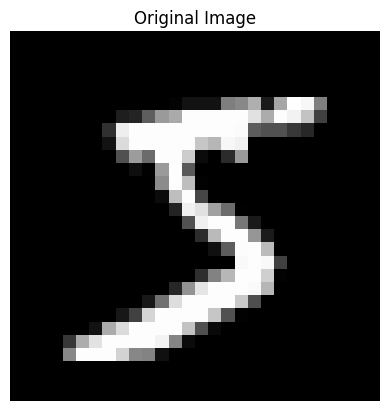

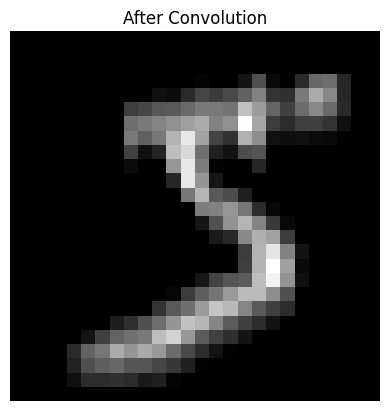

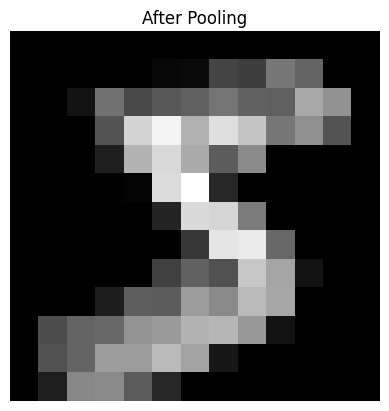

In [7]:
# Show original image
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Show convolution output
plt.imshow(output_conv[0, :, :, 0], cmap="gray")
plt.title("After Convolution")
plt.axis("off")
plt.show()

# Show pooling output
plt.imshow(output_pool[0, :, :, 0], cmap="gray")
plt.title("After Pooling")
plt.axis("off")
plt.show()


---

# 🧠 What we will SEE

* Original image → clear digit
* After convolution → pattern-focused image
* After pooling → smaller but still meaningful

---

# 🤖 Milo’s simple summary

```text id="2wllgf"
Pooling reduces the size of feature maps.
Max pooling keeps the strongest signal in each region.
It helps make the model faster and more efficient.
```

---

# 📊 Key takeaway table

| Concept     | Meaning                |
| ----------- | ---------------------- |
| Pooling     | reduce size            |
| Max pooling | keep max value         |
| 2×2 pooling | divide into 2×2 blocks |
| Output size | usually half           |

---



# 🧪 Practice

### Practice 1

```python id="8b7e7i"
layers.MaxPooling2D((3,3))
```

Ask:

```text id="7yqu4y"
Does output reduce more?
```

---

### Practice 2

Remove pooling layer

```python id="49u9m8"
# Comment out pooling
```

Ask:

```text id="z1hvcz"
Does size stay larger?
```

---

### Practice 3

Try Average Pooling

```python id="qpdzsz"
layers.AveragePooling2D((2,2))
```

Ask:

```text id="3qlkwu"
Do results look smoother?
```

---

